In [ ]:
# Section 1 - Question 1
# Customer Transaction Data Cleaning

import pandas as pd
import numpy as np

# -------------------------------------------------------
# (a) Create the DataFrame
# -------------------------------------------------------

data = {
    'CustomerID': [
        'C101', 'C102', 'C103', 'C104', 'C105',
        'C106', 'C107', 'C108', 'C108', 'C109'],

    'Name': [
        'Amit', 'Neha', 'Ravi', 'Priya', 'Amit',
        'Karan', 'Sonia', 'Meena', 'Meena', 'Rohan'],

    'City': [
        'Delhi', 'Mumbai', 'Delhi', 'Bengaluru', 'Delhi',
        'Delhi', 'Kolkata', 'Delhi', 'Delhi', 'Mumbai'],

    'Age': [
        25, 32, 29, np.nan, 25,
        41, 35, 27, 27, 31],

    'Amount': [
        1250, 2300, np.nan, 1850, 1250,
        4200, 2750, 1500, 1500, 3150],

    'Payment Mode': [
        'UPI', 'Card', 'Cash', 'Card', 'UPI',
        'Cash', 'UPI', 'Card', 'Card', 'UPI']}

df = pd.DataFrame(data)

print("Original DataFrame:")
print(df)

# -------------------------------------------------------
# (b) Summary statistics
# -------------------------------------------------------

print("\nSummary Statistics:")
print(df.describe(include='all'))

# -------------------------------------------------------
# (c) Missing values
# -------------------------------------------------------

print("\nNumber of Missing Values:")
print(df.isnull().sum())

print("\nRecords Containing Missing Values:")
print(df[df.isnull().any(axis=1)])

# -------------------------------------------------------
# (d) Fill missing numerical values using column mean
# -------------------------------------------------------

age_mean = df['Age'].mean()
amount_mean = df['Amount'].mean()

print("\nMean Age =", age_mean)
print("Mean Amount =", amount_mean)

df['Age'] = df['Age'].fillna(age_mean)
df['Amount'] = df['Amount'].fillna(amount_mean)

# -------------------------------------------------------
# (e) Remove duplicate records
# -------------------------------------------------------

before = len(df)

df = df.drop_duplicates()

after = len(df)

print("\nNumber of duplicate records removed:", before - after)

# -------------------------------------------------------
# (f) Final cleaned dataset
# -------------------------------------------------------

print("\nFinal Cleaned Dataset:")
print(df.round({'Age': 2, 'Amount': 2}))

Original DataFrame:
  CustomerID   Name       City   Age  Amount Payment Mode
0       C101   Amit      Delhi  25.0  1250.0          UPI
1       C102   Neha     Mumbai  32.0  2300.0         Card
2       C103   Ravi      Delhi  29.0     NaN         Cash
3       C104  Priya  Bengaluru   NaN  1850.0         Card
4       C105   Amit      Delhi  25.0  1250.0          UPI
5       C106  Karan      Delhi  41.0  4200.0         Cash
6       C107  Sonia    Kolkata  35.0  2750.0          UPI
7       C108  Meena      Delhi  27.0  1500.0         Card
8       C108  Meena      Delhi  27.0  1500.0         Card
9       C109  Rohan     Mumbai  31.0  3150.0          UPI

Summary Statistics:
       CustomerID  Name   City        Age       Amount Payment Mode
count          10    10     10   9.000000     9.000000           10
unique          9     8      4        NaN          NaN            3
top          C108  Amit  Delhi        NaN          NaN          UPI
freq            2     2      6        NaN        

In [ ]:
# Section 1 - Question 2
# Supermarket Sales Aggregation

import pandas as pd

data = {
    'OrderID': [
        'O101', 'O102', 'O103', 'O104', 'O105',
        'O106', 'O107', 'O108', 'O109', 'O110'],

    'Region': [
        'South', 'South', 'North', 'North', 'North',
        'South', 'South', 'North', 'North', 'South'],

    'Category': [
        'Grocery', 'Grocery', 'Clothing', 'Grocery',
        'Clothing', 'Clothing', 'Grocery', 'Clothing',
        'Clothing', 'Grocery'],

    'Sales': [
        5200, 6100, 18000, 4500, 24000,
        8200, 3900, 7600, 9100, 21000],

    'Profit': [
        650, 720, 3100, 480, 5200,
        1100, 420, 980, 1250, 4700]}

df = pd.DataFrame(data)

print("Original Data:")
print(df)

# -------------------------------------------------------
# (a) Region-wise total sales
# -------------------------------------------------------

region_sales = df.groupby('Region')['Sales'].sum()

print("\nTotal Sales by Region:")
print(region_sales)

# -------------------------------------------------------
# (b) Average profit for each category
# -------------------------------------------------------

category_profit = df.groupby('Category')['Profit'].mean()

print("\nAverage Profit by Category:")
print(category_profit)

# -------------------------------------------------------
# (c) Multiple aggregation functions
# -------------------------------------------------------

aggregated = df.groupby('Region').agg(
    Sales_Sum=('Sales', 'sum'),
    Sales_Mean=('Sales', 'mean'),
    Sales_Maximum=('Sales', 'max'))

# -------------------------------------------------------
# (d) Sort descending by total Sales
# -------------------------------------------------------

aggregated = aggregated.sort_values(
    by='Sales_Sum',
    ascending=False)

# -------------------------------------------------------
# (e) Final table
# -------------------------------------------------------

print("\nFinal Aggregated Table:")
print(aggregated)

Original Data:
  OrderID Region  Category  Sales  Profit
0    O101  South   Grocery   5200     650
1    O102  South   Grocery   6100     720
2    O103  North  Clothing  18000    3100
3    O104  North   Grocery   4500     480
4    O105  North  Clothing  24000    5200
5    O106  South  Clothing   8200    1100
6    O107  South   Grocery   3900     420
7    O108  North  Clothing   7600     980
8    O109  North  Clothing   9100    1250
9    O110  South   Grocery  21000    4700

Total Sales by Region:
Region
North    63200
South    44400
Name: Sales, dtype: int64

Average Profit by Category:
Category
Clothing    2326.0
Grocery     1394.0
Name: Profit, dtype: float64

Final Aggregated Table:
        Sales_Sum  Sales_Mean  Sales_Maximum
Region                                      
North       63200     12640.0          24000
South       44400      8880.0          21000


In [ ]:
# Section 1 - Question 3
# Data Merge, Pivot Table and Hierarchical Indexing

import pandas as pd

# -------------------------------------------------------
# Dataset A: Student Information
# -------------------------------------------------------

student_info = pd.DataFrame({
    'StudentID': ['S101', 'S102', 'S103', 'S104', 'S105'],

    'Name': [
        'Asha', 'Vivek', 'Mohit', 'Sneha', 'Riya'],

    'Department': [
        'Data Science', 'AI', 'Data Science',
        'Cyber Security', 'AI']})

# -------------------------------------------------------
# Dataset B: Semester Marks
# -------------------------------------------------------

marks = pd.DataFrame({
    'StudentID': ['S101', 'S102', 'S103', 'S104', 'S105'],

    'Marks in Python': [
        82, 74, 91, 69, 85],

    'Marks in Statistics': [
        78, 80, 88, 72, 81]})

# -------------------------------------------------------
# (a) Merge datasets
# -------------------------------------------------------

merged_df = pd.merge(
    student_info,
    marks,
    on='StudentID')

print("Merged DataFrame:")
print(merged_df)

# -------------------------------------------------------
# (b) Department-wise average marks
# -------------------------------------------------------

pivot = pd.pivot_table(
    merged_df,
    index='Department',
    values=['Marks in Python', 'Marks in Statistics'],
    aggfunc='mean')

print("\nDepartment-wise Average Marks:")
print(pivot)

# -------------------------------------------------------
# (c) Hierarchical index
# -------------------------------------------------------

hierarchical = merged_df.set_index(
    ['Department', 'StudentID'])

print("\nHierarchical DataFrame:")
print(hierarchical)

# -------------------------------------------------------
# (d) Rearrange index levels
# StudentID becomes Level 1
# Department becomes Level 2
# -------------------------------------------------------

rearranged = hierarchical.swaplevel(
    'Department',
    'StudentID')

rearranged = rearranged.sort_index()

# -------------------------------------------------------
# (e) Display final reshaped DataFrame
# -------------------------------------------------------

print("\nFinal Reshaped DataFrame:")
print(rearranged)

Merged DataFrame:
  StudentID   Name      Department  Marks in Python  Marks in Statistics
0      S101   Asha    Data Science               82                   78
1      S102  Vivek              AI               74                   80
2      S103  Mohit    Data Science               91                   88
3      S104  Sneha  Cyber Security               69                   72
4      S105   Riya              AI               85                   81

Department-wise Average Marks:
                Marks in Python  Marks in Statistics
Department                                          
AI                         79.5                 80.5
Cyber Security             69.0                 72.0
Data Science               86.5                 83.0

Hierarchical DataFrame:
                           Name  Marks in Python  Marks in Statistics
Department     StudentID                                             
Data Science   S101        Asha               82                   78
AI          

   Month  Product A  Product B  Product C
0    Jan         45         52         39
1    Feb         48         55         41
2    Mar         52         58         45
3    Apr         49         56         47
4    May         60         63         51
5    Jun         64         66         54
6    Jul         67         70         58
7    Aug         65         72         60
8    Sep         70         75         63
9    Oct         74         78         67
10   Nov         78         82         71
11   Dec         81         86         74


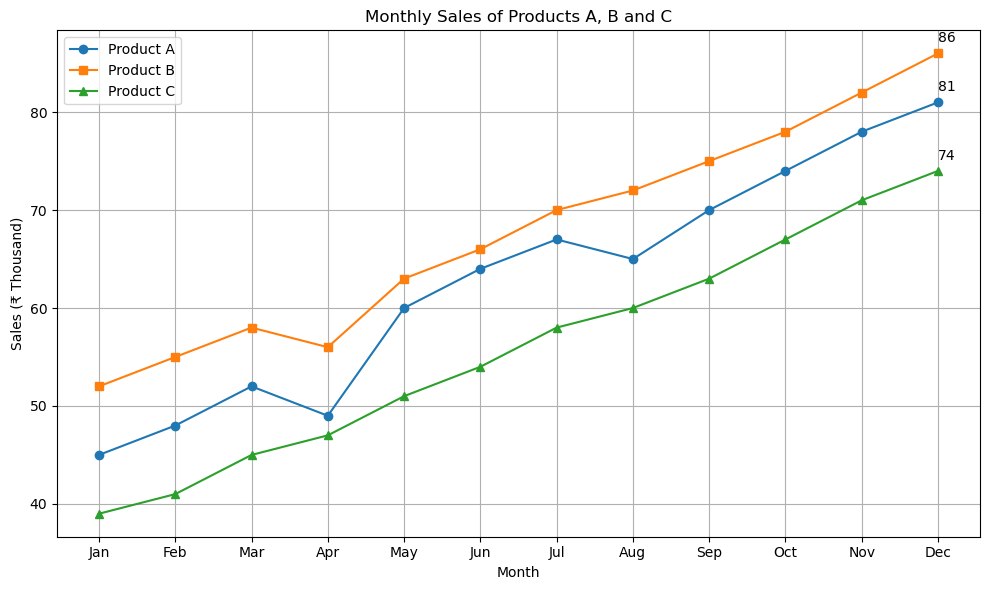

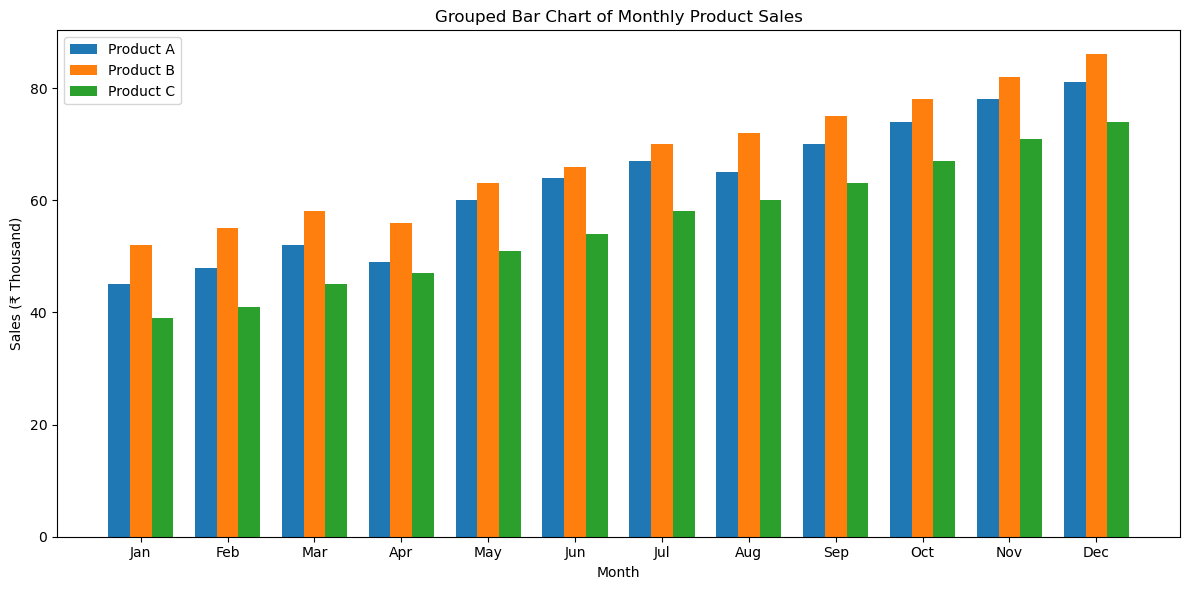

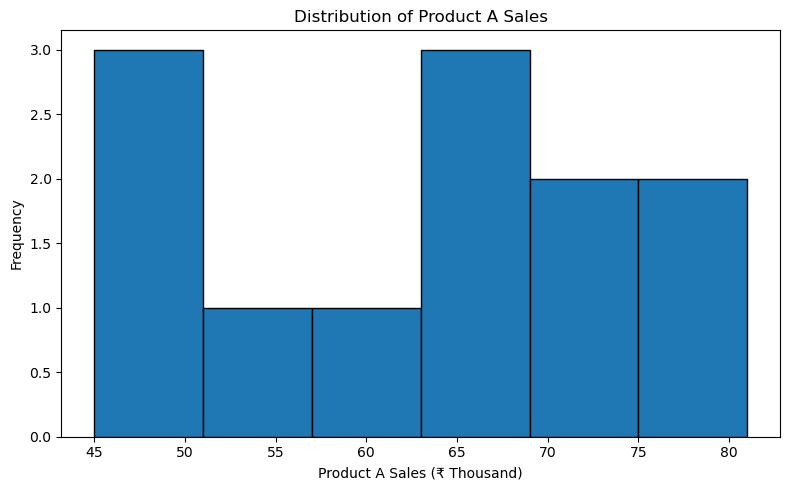

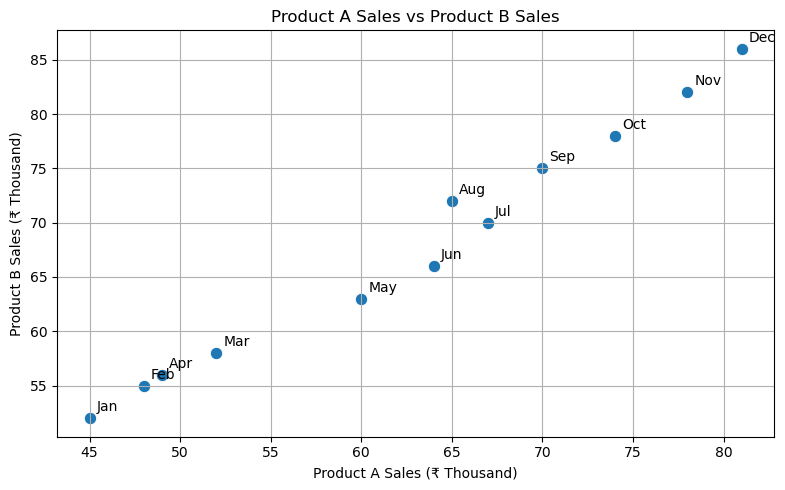


Correlation between Product A and Product B:
0.9908668107757018


In [ ]:
# Section 1 - Question 4
# Sales Visualisation using Matplotlib and Seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------
# Dataset
# -------------------------------------------------------

data = {
    'Month': [
        'Jan', 'Feb', 'Mar', 'Apr',
        'May', 'Jun', 'Jul', 'Aug',
        'Sep', 'Oct', 'Nov', 'Dec'],

    'Product A': [
        45, 48, 52, 49, 60, 64,
        67, 65, 70, 74, 78, 81],

    'Product B': [
        52, 55, 58, 56, 63, 66,
        70, 72, 75, 78, 82, 86],

    'Product C': [
        39, 41, 45, 47, 51, 54,
        58, 60, 63, 67, 71, 74]}

df = pd.DataFrame(data)

print(df)

# =======================================================
# (a) LINE PLOT
# =======================================================

plt.figure(figsize=(10, 6))

plt.plot(df['Month'], df['Product A'],
         marker='o', label='Product A')

plt.plot(df['Month'], df['Product B'],
         marker='s', label='Product B')

plt.plot(df['Month'], df['Product C'],
         marker='^', label='Product C')

plt.title('Monthly Sales of Products A, B and C')
plt.xlabel('Month')
plt.ylabel('Sales (₹ Thousand)')
plt.legend()
plt.grid(True)

# Annotate maximum values
for product in ['Product A', 'Product B', 'Product C']:

    max_index = df[product].idxmax()

    plt.annotate(
        str(df.loc[max_index, product]),
        (df.loc[max_index, 'Month'],
         df.loc[max_index, product]),
        xytext=(0, 8),
        textcoords='offset points')

plt.tight_layout()
plt.show()

# =======================================================
# (b) GROUPED BAR CHART
# =======================================================

x = np.arange(len(df['Month']))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - width, df['Product A'],
        width, label='Product A')

plt.bar(x, df['Product B'],
        width, label='Product B')

plt.bar(x + width, df['Product C'],
        width, label='Product C')

plt.xticks(x, df['Month'])

plt.title('Grouped Bar Chart of Monthly Product Sales')
plt.xlabel('Month')
plt.ylabel('Sales (₹ Thousand)')
plt.legend()

plt.tight_layout()
plt.show()

# =======================================================
# (c) HISTOGRAM FOR PRODUCT A
# =======================================================

plt.figure(figsize=(8, 5))

plt.hist(
    df['Product A'],
    bins=6,
    edgecolor='black')

plt.title('Distribution of Product A Sales')
plt.xlabel('Product A Sales (₹ Thousand)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# =======================================================
# (d) SCATTER PLOT PRODUCT A VS PRODUCT B
# =======================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df['Product A'],
    y=df['Product B'],
    s=80)

plt.title('Product A Sales vs Product B Sales')
plt.xlabel('Product A Sales (₹ Thousand)')
plt.ylabel('Product B Sales (₹ Thousand)')
plt.grid(True)

# Annotate months
for i in range(len(df)):

    plt.annotate(
        df.loc[i, 'Month'],
        (df.loc[i, 'Product A'],
         df.loc[i, 'Product B']),
        xytext=(5, 5),
        textcoords='offset points')

plt.tight_layout()
plt.show()

# Correlation for interpretation
correlation = df['Product A'].corr(df['Product B'])

print("\nCorrelation between Product A and Product B:")
print(correlation)

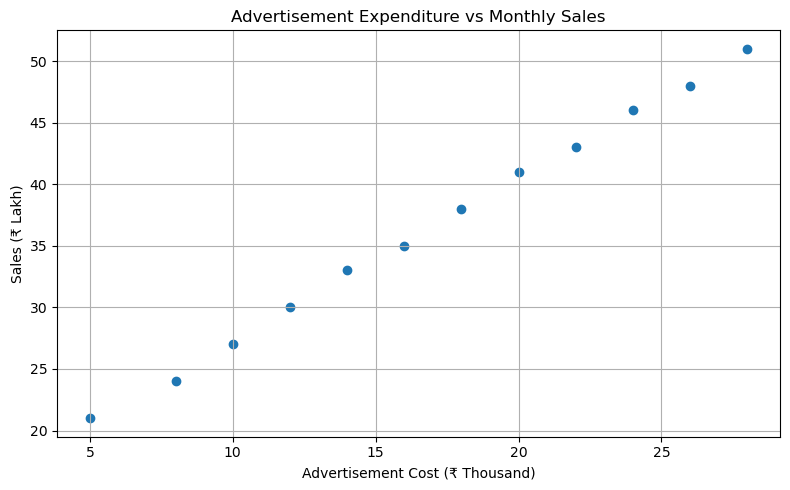

Regression slope = 1.321893822664238
Regression intercept = 14.05462949992996
R-squared = 0.9986960214940693


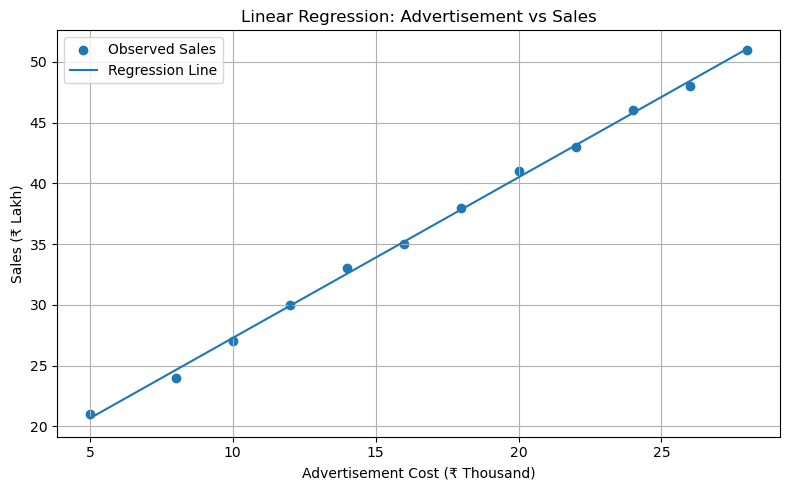

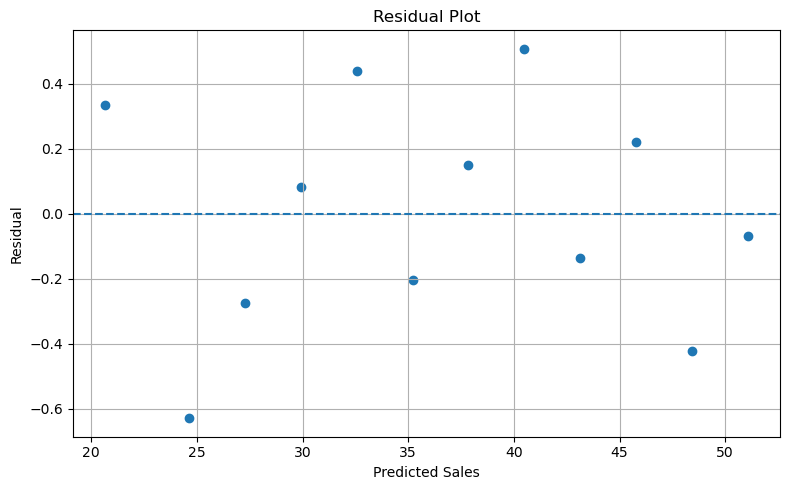

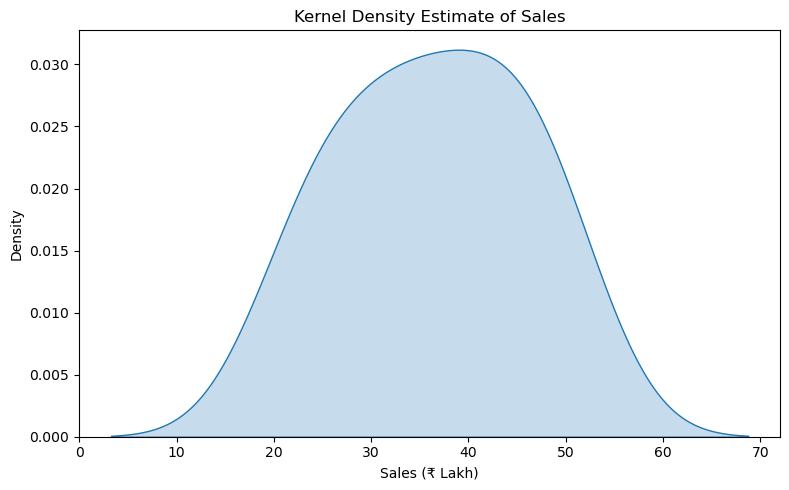

In [ ]:
# Section 1 - Question 5
# Advertisement versus Sales Regression Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------
# Dataset
# -------------------------------------------------------

advertisement = np.array(
    [5, 8, 10, 12, 14, 16,
     18, 20, 22, 24, 26, 28],
    dtype=float)

sales = np.array(
    [21, 24, 27, 30, 33, 35,
     38, 41, 43, 46, 48, 51],
    dtype=float)

df = pd.DataFrame({
    'Advertisement': advertisement,
    'Sales': sales})

# -------------------------------------------------------
# (a) Scatter plot
# -------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df['Advertisement'],
    df['Sales'])

plt.title('Advertisement Expenditure vs Monthly Sales')
plt.xlabel('Advertisement Cost (₹ Thousand)')
plt.ylabel('Sales (₹ Lakh)')
plt.grid(True)

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# (b) Simple linear regression
# -------------------------------------------------------

slope, intercept = np.polyfit(
    advertisement,
    sales,
    1)

predicted_sales = (
    intercept +
    slope * advertisement)

print("Regression slope =", slope)
print("Regression intercept =", intercept)

# R-squared calculation

ss_res = np.sum(
    (sales - predicted_sales) ** 2)

ss_tot = np.sum(
    (sales - sales.mean()) ** 2)

r_squared = 1 - ss_res / ss_tot

print("R-squared =", r_squared)

# Regression plot

plt.figure(figsize=(8, 5))

plt.scatter(
    advertisement,
    sales,
    label='Observed Sales')

plt.plot(
    advertisement,
    predicted_sales,
    label='Regression Line')

plt.title('Linear Regression: Advertisement vs Sales')
plt.xlabel('Advertisement Cost (₹ Thousand)')
plt.ylabel('Sales (₹ Lakh)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# (c) Residual plot
# -------------------------------------------------------

residuals = sales - predicted_sales

plt.figure(figsize=(8, 5))

plt.scatter(
    predicted_sales,
    residuals)

plt.axhline(
    y=0,
    linestyle='--')

plt.title('Residual Plot')
plt.xlabel('Predicted Sales')
plt.ylabel('Residual')
plt.grid(True)

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# (d) KDE plot
# -------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=df,
    x='Sales',
    fill=True)

plt.title('Kernel Density Estimate of Sales')
plt.xlabel('Sales (₹ Lakh)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()